In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import librosa
import librosa.display
import os
# Regex
import re
# Useful for fourier stuff
from scipy.signal import find_peaks

In [ ]:
# Establish the file paths necessary for feature transformation
pop_path = "/Users/tarush/Desktop/STA-395/Data/Music/genres_original/pop"
rock_path = "/Users/tarush/Desktop/STA-395/Data/Music/genres_original/rock"
hiphop_path = "/Users/tarush/Desktop/STA-395/Data/Music/genres_original/hiphop"

In [3]:
# For some testing, I will pull the first 5 songs from each folder.
folder_paths = [pop_path, rock_path, hiphop_path]

In [4]:
"""
Return a list of full filepaths for all files inside a directory.

Parameters
----------
path : str
    The path to the folder whose contents you want to list.

Returns
-------
list of str
    A list containing the full filepaths of every item in the directory.
    The filenames are sorted alphabetically to ensure consistent ordering.
"""
def list_folder(path):
    filenames = sorted(os.listdir(path)) 
    return [os.path.join(path, f) for f in filenames]

files = list(map(list_folder, folder_paths))

In [5]:
"""
Given a list of lists, with the lists being full of files in different classes,
create a 1d list of the first n observations in each class/path.

Parameters
----------
path : list
    A list of lists, with the innermost lists containing file paths
n : int
    The number of objects we want from each class.

Returns
-------
data : list
    A 1d list of the first n observations in each class/path.
"""
def create_data(paths, n):
    data = list()
    i = 0
    while i < len(paths):
        j = 0
        while j < n:
           data.append(paths[i][j])
           j += 1
        i += 1
    return data

In [6]:
"""
Extract and return the classification label of a file based on its directory.

Parameters
----------
path : str
    The full filepath to an audio file.

Returns
-------
str
    The name of the directory that directly contains the file. This is
    treated as the file's classification label.
"""
def get_file_class(path):
    return os.path.basename(os.path.dirname(path))

In [7]:
# Now, we have our "label" and "data" split or y and X
selected_files = create_data(files, 50)
file_classes = list(map(get_file_class, selected_files))
print(file_classes[:3])

# name_to_int
def name_to_int(name):
    if name == "hiphop":
        return 0
    elif name == "pop":
        return 1
    else:
        return 2

# Convert file classes to integers
file_classes = list(map(name_to_int, file_classes))

# For example:
print(file_classes[:3])
print(selected_files[:3])

['pop', 'pop', 'pop']
[1, 1, 1]
['/Users/finnrowles/Documents/STA-395/STA-395_Project/Data/genres_original/pop/pop.00000.wav', '/Users/finnrowles/Documents/STA-395/STA-395_Project/Data/genres_original/pop/pop.00001.wav', '/Users/finnrowles/Documents/STA-395/STA-395_Project/Data/genres_original/pop/pop.00002.wav']


In [18]:
# Feature expansion...
# How can we extract rhythm, melody, harmony, tempo, and instrumentation?
# Use overtone analysis, extract tempo, centroids?
def extract_features(path):
    y, sr = librosa.load(path, sr=None)
    
    # Traditional features from fundemental frequency translation
    f0, _, _ = librosa.pyin(
        y,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7")
    )
    # Replace NaNs with 0, common fix for some random bugs
    # Note! I think this will lead to problematic features down the line
    f0_clean = np.nan_to_num(f0)
    melodic_features = np.array([
        f0_clean.mean(),
        f0_clean.std(),
        f0_clean.max(),
    ])
    
    # Some harmonic analysis
    # stft : fourier transformation
    # We use this to to analyze a songs constituent frequencies, 
    # turning a complex sound wave into a spectrum of individual 
    # frequencies and their amplitudes
    S = np.abs(librosa.stft(y))
    # Individual note frequencies?
    freqs = librosa.fft_frequencies(sr=sr)
    frame = 500  # arbitrary mid-point frame (recommended by stack overflow)
    spectrum_slice = S[:, frame]

    peaks, _ = find_peaks(spectrum_slice, height=np.max(spectrum_slice)*0.1)
    # The frequency at each "slice" of the song
    peak_freqs = freqs[peaks]
    peak_amps = spectrum_slice[peaks]
    f0_val = f0[frame] if not np.isnan(f0[frame]) else 1.0  # Avoid divide by zero, no NaN values
    
    harmonic_ratios = np.array(peak_freqs / f0_val)
    
    harmonic_ratios_fixed = np.zeros(4)
    n = min(len(harmonic_ratios), 4)
    harmonic_ratios_fixed[:n] = harmonic_ratios[:n]
    
    # Tempo
    tempo = np.array(librosa.feature.tempo(y=y, sr=sr)[0:1])
    
    # Root mean square energy
    rms_vals = librosa.feature.rms(y=y)
    
    # Spectral centroid
    centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    
    rms_cent_features = np.array([
        np.mean(rms_vals),
        np.std(rms_vals),
        np.min(rms_vals),
        np.max(rms_vals),
        np.mean(centroids),
        np.std(centroids),
        np.min(centroids),
        np.max(centroids),
    ])
    
    
    return np.concatenate([
        melodic_features,
        harmonic_ratios_fixed,
        tempo,
        rms_cent_features
    ])

In [19]:
# test = extract_features(selected_files[0])
# test

In [20]:
# Where o1 - o9 are the harmonic ratios throughout the song.?
# Have yet to add centroids and more complex features.
df = pd.DataFrame(columns=[
    "mean_freq","std_freq","max_freq",
    "o1","o2","o3","o4",
    "tempo",
    'rms_mean','rms_std','rms_min','rms_max',
    'centroid_mean','centroid_std','centroid_min','centroid_max',
])

df = pd.DataFrame(df)
for file in selected_files:
    row = extract_features(file)
    features = pd.DataFrame([row], columns=df.columns)
    df = pd.concat([df, features], ignore_index=True)

,mean_freq,std_freq,max_freq,o1,o2,o3,o4,tempo,rms_mean,rms_std,rms_min,rms_max,centroid_mean,centroid_std,centroid_min,centroid_max
0,85.213745,119.276868,460.809414,0.823054,1.810719,2.304552,3.456828,135.999178,0.185783,0.08669,0.023249,0.492508,3422.071864,1039.287259,509.940032,7532.942458
1,19.894057,30.671182,87.812822,0.450238,1.050556,1.951032,3.001588,107.666016,0.262244,0.121823,0.021256,0.568401,3702.062803,1184.939731,622.671588,8516.067561
2,39.975805,64.221217,450.284512,0.482553,0.965107,1.608511,2.091065,129.199219,0.215087,0.081207,0.045358,0.393026,3214.019678,1003.211146,962.10582,5720.480353
3,56.331243,40.168243,225.142256,96.899414,193.798828,247.631836,398.364258,92.285156,0.129341,0.042554,0.049555,0.335516,1837.492826,887.357763,573.570928,7582.089487
4,22.157284,34.968672,117.895081,53.833008,107.666016,161.499023,226.098633,107.666016,0.211077,0.050752,0.085962,0.370069,2753.234723,847.236424,934.619558,6526.857952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,71.487259,117.814198,706.572136,0.998464,1.996928,0.0,0.0,95.703125,0.184495,0.095172,0.0,0.483273,2693.21766,1249.84573,0.0,7987.022663
146,40.193788,53.859977,263.141147,53.833008,75.366211,139.96582,215.332031,95.703125,0.227984,0.133981,0.017604,0.591348,2306.89106,950.331442,468.478946,6062.711698
147,63.720518,59.208277,211.282048,0.881436,1.036983,1.659173,1.814721,95.703125,0.247004,0.120887,0.016487,0.610613,3235.555809,1133.474906,1057.632798,7333.034267
148,57.571231,50.431981,207.652349,32.299805,75.366211,129.199219,161.499023,95.703125,0.23028,0.111437,0.010078,0.511885,2345.299207,926.107034,367.637199,4775.154967


In [23]:
df = df.astype(float)
df

,mean_freq,std_freq,max_freq,o1,o2,o3,o4,tempo,rms_mean,rms_std,rms_min,rms_max,centroid_mean,centroid_std,centroid_min,centroid_max
0,85.213745,119.276868,460.809414,0.823054,1.810719,2.304552,3.456828,135.999178,0.185783,0.086690,0.023249,0.492508,3422.071864,1039.287259,509.940032,7532.942458
1,19.894057,30.671182,87.812822,0.450238,1.050556,1.951032,3.001588,107.666016,0.262244,0.121823,0.021256,0.568401,3702.062803,1184.939731,622.671588,8516.067561
2,39.975805,64.221217,450.284512,0.482553,0.965107,1.608511,2.091065,129.199219,0.215087,0.081207,0.045358,0.393026,3214.019678,1003.211146,962.105820,5720.480353
3,56.331243,40.168243,225.142256,96.899414,193.798828,247.631836,398.364258,92.285156,0.129341,0.042554,0.049555,0.335516,1837.492826,887.357763,573.570928,7582.089487
4,22.157284,34.968672,117.895081,53.833008,107.666016,161.499023,226.098633,107.666016,0.211077,0.050752,0.085962,0.370069,2753.234723,847.236424,934.619558,6526.857952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,71.487259,117.814198,706.572136,0.998464,1.996928,0.000000,0.000000,95.703125,0.184495,0.095172,0.000000,0.483273,2693.217660,1249.845730,0.000000,7987.022663
146,40.193788,53.859977,263.141147,53.833008,75.366211,139.965820,215.332031,95.703125,0.227984,0.133981,0.017604,0.591348,2306.891060,950.331442,468.478946,6062.711698
147,63.720518,59.208277,211.282048,0.881436,1.036983,1.659173,1.814721,95.703125,0.247004,0.120887,0.016487,0.610613,3235.555809,1133.474906,1057.632798,7333.034267
148,57.571231,50.431981,207.652349,32.299805,75.366211,129.199219,161.499023,95.703125,0.230280,0.111437,0.010078,0.511885,2345.299207,926.107034,367.637199,4775.154967


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df, file_classes,
    test_size=0.2)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

my_pipeline = Pipeline([
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        random_state=42
    ))
])

my_params = {
    'classifier__n_estimators': [100, 150, 200],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.5, 0.8],
    'classifier__colsample_bytree': [1.0]
}


In [32]:
from sklearn.model_selection import GridSearchCV

grid_results = GridSearchCV(my_pipeline, my_params, cv=3, scoring='accuracy').fit(X_train, y_train)
pd.DataFrame(grid_results.cv_results_).sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__colsample_bytree,param_classifier__learning_rate,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__subsample,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
47,0.114375,0.002614,0.005995,0.000579,1.0,0.1,9,200,0.8,"{'classifier__colsample_bytree': 1.0, 'classif...",0.800,0.750,0.8,0.783333,0.023570,1
2,0.290147,0.277971,0.005793,0.000392,1.0,0.05,3,150,0.5,"{'classifier__colsample_bytree': 1.0, 'classif...",0.775,0.775,0.8,0.783333,0.011785,1
41,0.116765,0.001325,0.005700,0.000230,1.0,0.1,7,200,0.8,"{'classifier__colsample_bytree': 1.0, 'classif...",0.800,0.750,0.8,0.783333,0.023570,1
35,0.115400,0.002722,0.005703,0.000080,1.0,0.1,5,200,0.8,"{'classifier__colsample_bytree': 1.0, 'classif...",0.800,0.750,0.8,0.783333,0.023570,1
26,0.083540,0.001280,0.005331,0.000041,1.0,0.1,3,150,0.5,"{'classifier__colsample_bytree': 1.0, 'classif...",0.775,0.775,0.8,0.783333,0.011785,1


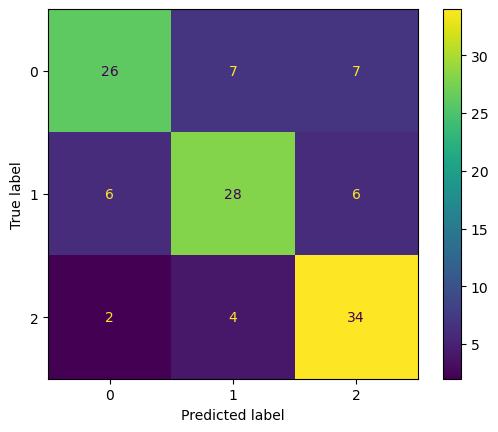

In [33]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict 

train_y_pred = cross_val_predict(estimator = grid_results.best_estimator_, X = X_train, y = y_train, cv = 5, method = 'predict')

## Confusion matrix:
confusion_matrix(y_true = y_train, y_pred = train_y_pred)

ConfusionMatrixDisplay.from_predictions(y_train, train_y_pred)
plt.show()

Try: rolling window standard deviations, 

TIME domain: sound waves, original y, sr
Frequency domain: band energy ratio, spectral centroid, spectral flux (fourier transformation)
Time-frequency features: ??

# Common features
Amplitude envelope
Root-mean square energy
Zero crossing rate
Band energy ratio
Spectral centroid 
Spectral spread
Spectral roll off

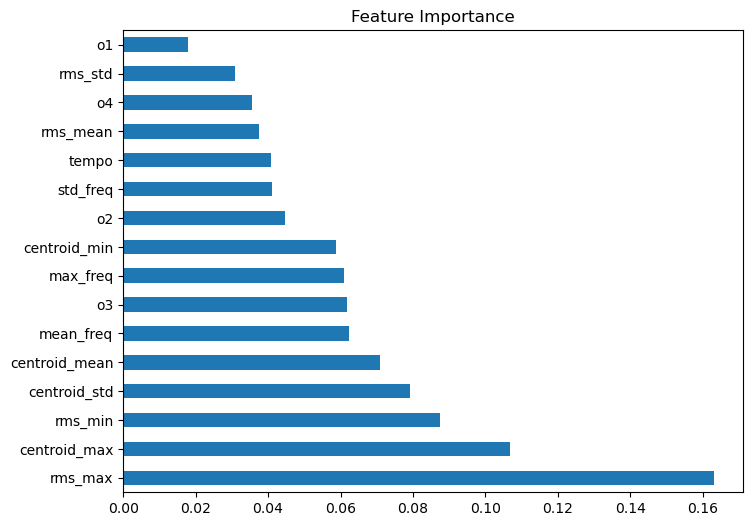

In [38]:
best_model = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None, num_class=3).fit(X_train, y_train) 

feature_names = X_train.columns
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, feature_names).sort_values(ascending=False)

feat_imp.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [34]:
grid_results.best_estimator_

Pipeline(steps=[('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=1.0, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=None, num_class=3, ...))])